# Logistic Regression
- 선형 회귀 모델을 기반으로 확률을 예측하는 모델
- 분류에서 사용 가능 (이항 분류를 기본으로 사용)

```python
from sklearn.linear_model import LogisticRegression
```

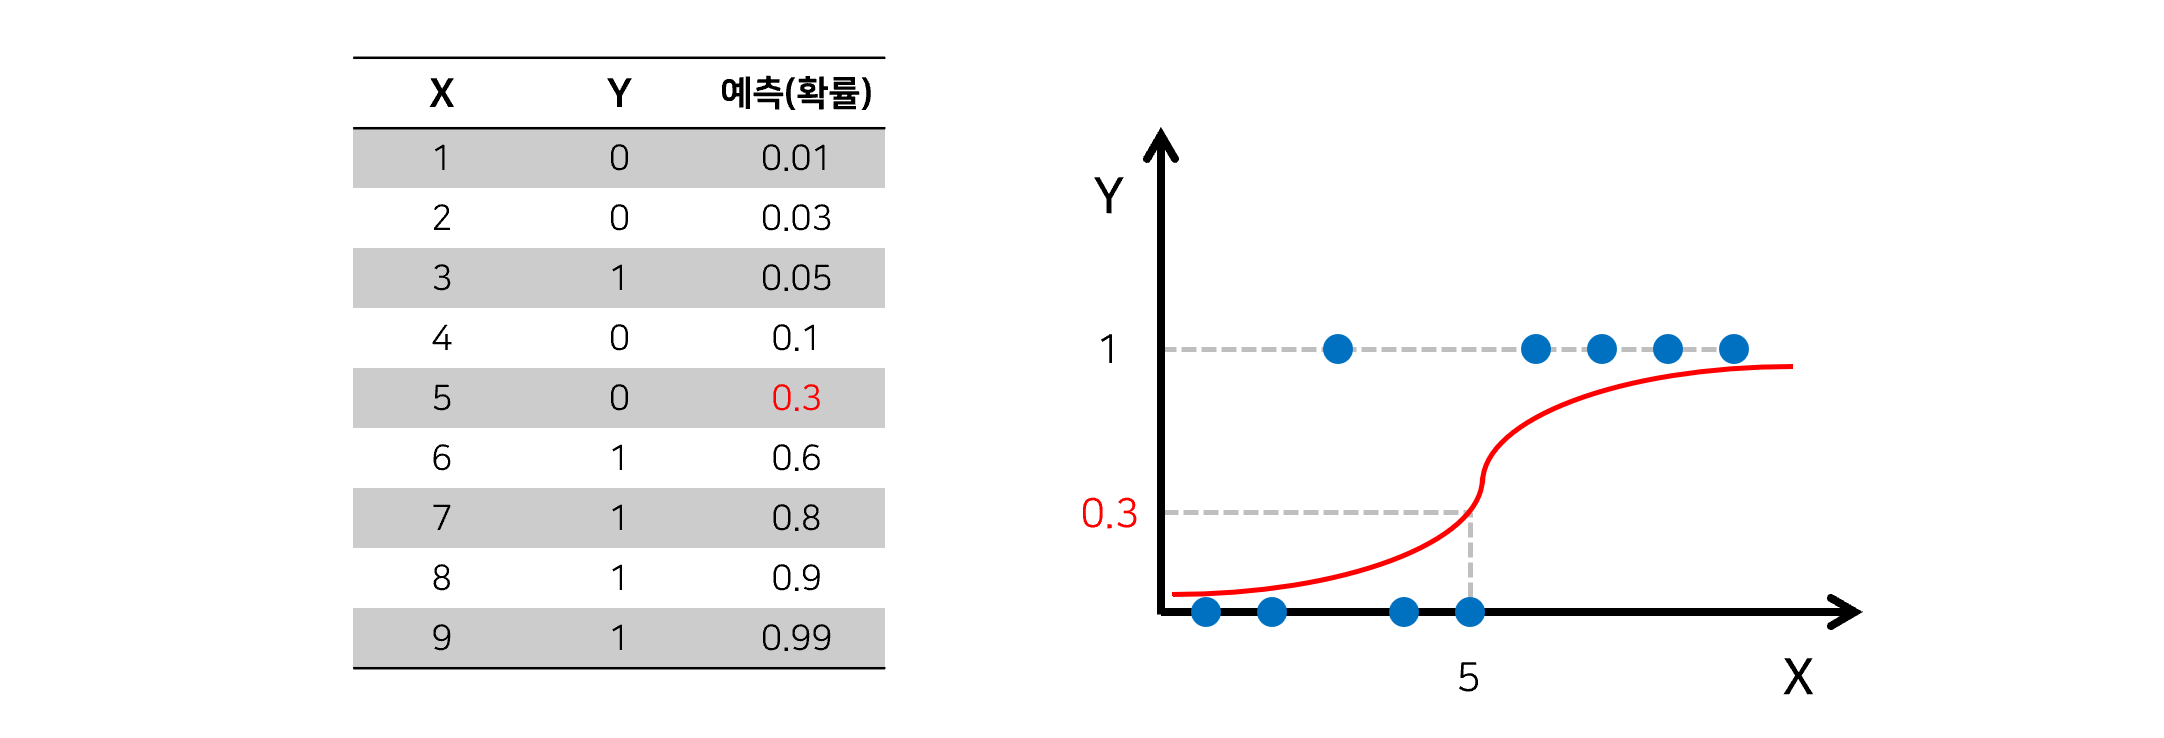


<br/>
<br/>

In [ ]:
# Google Colab 환경에서만 실행
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [23]:
# (코드 실행)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'NanumGothic' # NanumGothic
plt.rcParams['axes.unicode_minus'] = False

,공부시간,합격여부
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
5,6,1
6,7,0
7,8,1
8,9,1
9,11,1


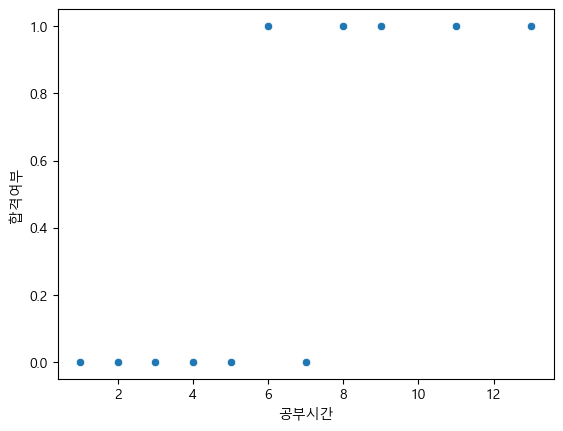

In [24]:
# (코드 실행) 데이터 생성
df = pd.DataFrame({
    '공부시간' : [1,2,3,4,5,6,7,8,9,11,13],
    '합격여부' : [0,0,0,0,0,1,0,1,1,1,1]
})
display(df)

sns.scatterplot(x='공부시간', y='합격여부', data=df)
plt.show()

In [25]:
# X, y 분리
X = df.drop('합격여부', axis = 1)
y = df['합격여부']

In [26]:
# 선형회귀 모델 적용
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)
pred

array([-0.12531969, -0.01534527,  0.09462916,  0.20460358,  0.31457801,
        0.42455243,  0.53452685,  0.64450128,  0.7544757 ,  0.97442455,
        1.1943734 ])

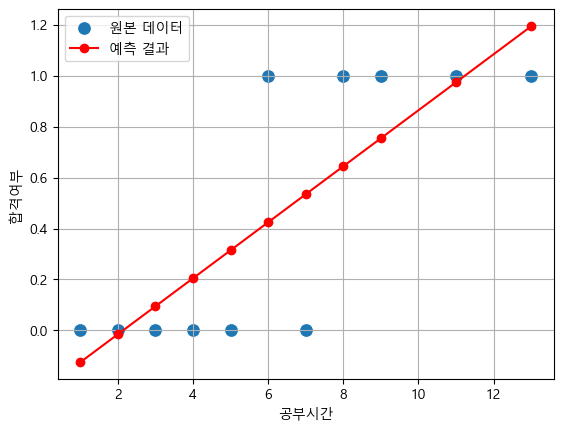

In [27]:
# 예측 결과 시각화
sns.scatterplot(x='공부시간', y='합격여부', data=df, s = 100, label='원본 데이터')
plt.plot(X.values, pred, c = 'red', marker = 'o', label = '예측 결과')
plt.legend()
plt.grid()
plt.show()

In [28]:
# 로지스틱 회귀 모델 적용
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)
pred = model.predict(X)
pred

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

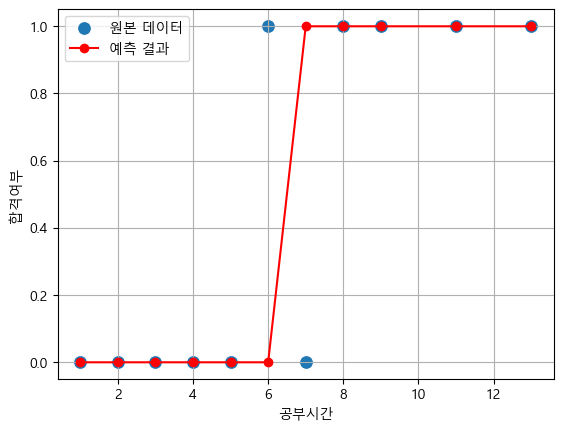

In [29]:
# 예측 결과 시각화
sns.scatterplot(x='공부시간', y='합격여부', data=df, s = 100, label='원본 데이터')
plt.plot(X.values, pred, c = 'red', marker = 'o', label = '예측 결과')
plt.legend()
plt.grid()
plt.show()

In [30]:
# 확률 예측
# 확률을 반올림하여 class(0 혹은 1) 예측
pred = model.predict_proba(X)
pred

array([[0.99269115, 0.00730885],
       [0.9824749 , 0.0175251 ],
       [0.95857436, 0.04142564],
       [0.90522292, 0.09477708],
       [0.7976644 , 0.2023356 ],
       [0.61936807, 0.38063193],
       [0.40178658, 0.59821342],
       [0.2170536 , 0.7829464 ],
       [0.10267833, 0.89732167],
       [0.01912216, 0.98087784],
       [0.00331035, 0.99668965]])

In [31]:
# 1일 확률
pred[:, 1]

array([0.00730885, 0.0175251 , 0.04142564, 0.09477708, 0.2023356 ,
       0.38063193, 0.59821342, 0.7829464 , 0.89732167, 0.98087784,
       0.99668965])

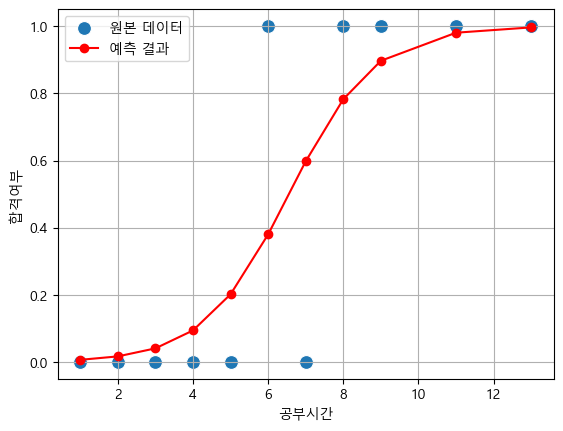

In [32]:
# 예측 결과 시각화
sns.scatterplot(x='공부시간', y='합격여부', data=df, s = 100, label='원본 데이터')
plt.plot(X.values, pred[:, 1], c = 'red', marker = 'o', label = '예측 결과')
plt.legend()
plt.grid()
plt.show()

<br/>
<br/>

### [연습문제]

,유튜브 시청시간,합격여부
0,1,1
1,2,1
2,3,1
3,4,0
4,5,1
5,6,0
6,7,0
7,8,1
8,9,0
9,10,0


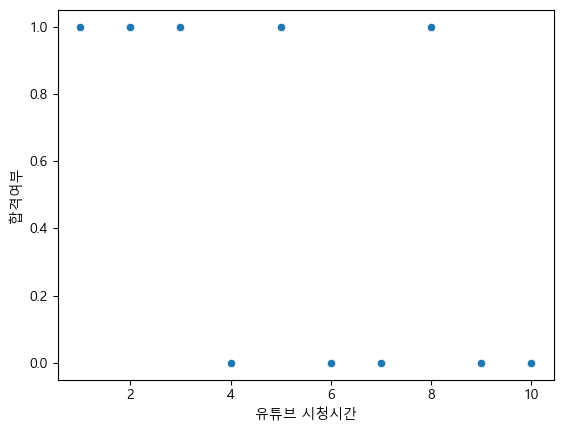

In [33]:
# (코드 실행) 데이터 생성
df = pd.DataFrame({
    '유튜브 시청시간' : [1,2,3,4,5,6,7,8,9,10],
    '합격여부' : [1,1,1,0,1,0,0,1,0,0]
})
display(df)

sns.scatterplot(x='유튜브 시청시간', y='합격여부', data=df)
plt.show()

In [34]:
# X, y 분리
X = df.drop('합격여부', axis = 1)
y = df['합격여부']

In [35]:
# 로지스틱 회귀 모델을 이용하여 합격여부를 예측하세요.
model = LogisticRegression()
model.fit(X, y)
pred = model.predict(X)
pred

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

In [36]:
# 위의 결과를 "합격예측" 열에 추가하세요.
df['합격예측'] = pred
df

,유튜브 시청시간,합격여부,합격예측
0,1,1,1
1,2,1,1
2,3,1,1
3,4,0,1
4,5,1,1
5,6,0,0
6,7,0,0
7,8,1,0
8,9,0,0
9,10,0,0


In [37]:
# 로지스틱 회귀 모델을 이용하여 합격 확률을 구하세요.
pred = model.predict_proba(X)[:,1]
pred

array([0.90135066, 0.84821652, 0.77365033, 0.67642639, 0.5611314 ,
       0.43883613, 0.32354476, 0.22632659, 0.15176651, 0.09863762])

In [38]:
# 위의 결과를 "합격확률" 열에 추가하세요.
df['합격확률'] = pred
df

,유튜브 시청시간,합격여부,합격예측,합격확률
0,1,1,1,0.901351
1,2,1,1,0.848217
2,3,1,1,0.773650
3,4,0,1,0.676426
4,5,1,1,0.561131
5,6,0,0,0.438836
6,7,0,0,0.323545
7,8,1,0,0.226327
8,9,0,0,0.151767
9,10,0,0,0.098638


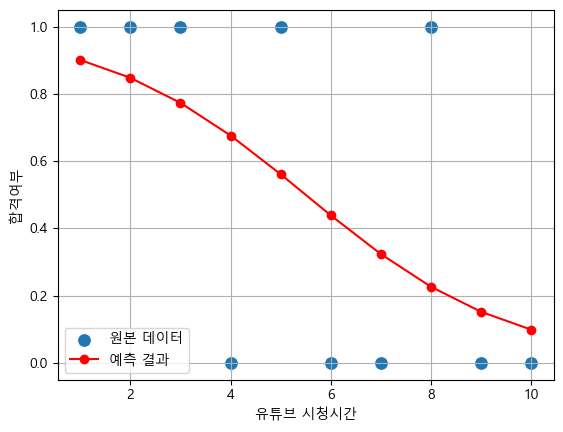

In [39]:
# 예측 결과 시각화
sns.scatterplot(x='유튜브 시청시간', y='합격여부', data=df, s = 100, label='원본 데이터')
plt.plot(X.values, pred, c = 'red', marker = 'o', label = '예측 결과')
plt.legend()
plt.grid()
plt.show()

<br/>
<br/>

### [연습문제]

In [40]:
# cancer.csv 파일을 읽으세요. - 이진 분류
df = pd.read_csv('cancer.csv')
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,cancer
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [41]:
# X, y 분리
X = df.drop('cancer', axis = 1)
y = df['cancer']

In [42]:
# 학습, 검증 데이터 분리
# random_state = 0
# stratify = y
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state = 0,
                                                    stratify = y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((426, 30), (143, 30), (426,), (143,))

In [43]:
# 로지스틱 회귀 모델을 이용하여 데이터를 학습하고 정답율을 구하세요.
model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_train, y_train), model.score(X_test, y_test)

(0.9553990610328639, 0.9230769230769231)

In [44]:
# 검증 데이터의 예측 결과를 구하세요.
pred = model.predict(X_test)
pred

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0])